In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torchvision
import torchvision.transforms as transforms
from torchinfo import summary
from typing import Tuple, Optional, Literal
import matplotlib.pyplot as plt
from tqdm import tqdm

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.cuda.empty_cache()
torch.backends.cudnn.benchmark = True

In [2]:
# ============================================================================
# PART 1: VAE 
# ============================================================================
class VAE(nn.Module):
    def __init__(self, 
                 data_dim: int, 
                 latent_dim: int = 20, 
                 hidden_dim: int = 256,
                 encoder_layers: int = 2,
                 data_type: Optional[Literal['binary', 'continuous', 'auto']] = 'auto'
                 ):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder_layers = encoder_layers
        self.data_type = data_type

        currentDim = data_dim
        layers = []
        for i in range(encoder_layers):
            nextDim = hidden_dim if i ==0 else hidden_dim//2
            layers.append(nn.Linear(currentDim, nextDim))
            layers.append(nn.Tanh())
            currentDim = nextDim
        self.encodeLayers=nn.Sequential(*layers)
        self.fc_mu = nn.Linear(currentDim, latent_dim)
        self.fc_logvar = nn.Linear(currentDim, latent_dim)

        currentDim = latent_dim
        layers = []
        for i in range(encoder_layers-1):
            nextDim = hidden_dim
            layers.append(nn.Linear(currentDim, nextDim))
            layers.append(nn.Tanh())
            currentDim = nextDim
        layers.append(nn.Linear(hidden_dim, data_dim))
        layers.append(nn.Sigmoid())
        self.decoder_bernoulli = nn.Sequential(*layers)

        currentDim = latent_dim
        layers = []
        for i in range(encoder_layers):
            nextDim = hidden_dim
            layers.append(nn.Linear(currentDim, nextDim))
            layers.append(nn.Tanh())
            currentDim = nextDim
        self.decoder_gaussian_layers = nn.Sequential(*layers)
        self.decoder_gaussian_mean = nn.Linear(hidden_dim, data_dim)
        self.decoder_gaussian_logvar = nn.Linear(hidden_dim, data_dim)

        self.prior_mean = torch.zeros(latent_dim)
        self.prior_std = torch.ones(latent_dim)
    
    def detect_data_type(self, x: torch.Tensor) -> str:
        unique_vals =torch.unique(x[0:2].flatten())
        if len(unique_vals) <= 2:
            print(f"Auto-detected: Binary data (unique values: {unique_vals.tolist()})")
            return 'binary'
        else:
            print(f"Auto-detected: Continuous data ({len(unique_vals)} unique values)")
            return 'continuous'

    def encode(self, x: torch.Tensor) -> tuple:
        h = self.encodeLayers(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z: torch.Tensor) -> torch.Tensor:
        if (self.data_type is None)or(self.data_type=='auto') :
            self.data_type = self.detect_data_type(z)
        if self.data_type == 'binary':
            return self.decoder_bernoulli(z), None
        else:
            h = self.decoder_gaussian_layers(z)
            return self.decoder_gaussian_mean(h), self.decoder_gaussian_logvar(h)
    
    def sample_prior(self, num_samples: int) -> torch.Tensor:

        return torch.randn(num_samples, self.latent_dim)
    
    def forward(self,x: torch.Tensor,data_type: Optional[str] = None) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        if (self.data_type is None)or(self.data_type=='auto') :
            self.data_type = self.detect_data_type(x)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar
    
    def reconstruction_loss(self, x: torch.Tensor, recon_output, mu: torch.Tensor, 
                          logvar: torch.Tensor, data_type: Optional[str] = None) -> torch.Tensor:
        if data_type is None:
            data_type = self.data_type
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        if data_type == 'binary':
            if isinstance(recon_output, tuple):
                recon_output=recon_output[0]
            recon_loss = nn.functional.binary_cross_entropy(recon_output, x, reduction='sum')
        else:  # 'continuous'
            mean, logvar_x = recon_output
            var_x = torch.exp(logvar_x)
            recon_loss = 0.5 * torch.sum(torch.log(2 * torch.pi * var_x) + (x - mean).pow(2) / var_x)
        return recon_loss + kl_loss,recon_loss,kl_loss
    
    def generate(self, num_samples: int = 1, z: Optional[torch.Tensor] = None):
        if z is None:
            z = self.sample_prior(num_samples)
        recon_x = self.decode(z)
        if isinstance(recon_x, tuple):
            return recon_x[0]
        return recon_x


In [11]:
def visualize_reconstructions(vae_model, data_loader, num_images=8, epoch=0):
    """Visualize original and reconstructed images"""
    vae_model.eval()
    with torch.no_grad():
        data, _ = next(iter(data_loader))
        data_dim=data.shape[1]
        data = data[:num_images]
        if isinstance(data, tuple):
            data = data[0]
        data_flat = data.view(data.size(0), -1)
        recon_output, mu, logvar = vae_model(data_flat)
        if isinstance(recon_output, tuple):
            recon_x = recon_output[0]
        else:
            recon_x = recon_output
        img_size = int(np.sqrt(data_dim))
        fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))
        for i in range(num_images):
            orig_img = data[i].view(img_size, img_size).cpu().numpy()
            axes[0, i].imshow(orig_img, cmap='gray')
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title('Original')
            recon_img = recon_x[i].view(img_size, img_size).cpu().numpy()
            axes[1, i].imshow(recon_img, cmap='gray')
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title('Reconstructed')
        plt.suptitle(f'Epoch {epoch}', y=1.05)
        plt.tight_layout()
        # plt.savefig(f'reconstructions_epoch_{epoch:04d}.png', bbox_inches='tight', dpi=100)
        # plt.close()
        plt.show()
    vae_model.train()

def visualize_latent_space(vae_model, data_loader, num_samples=1000, epoch=0):
    if vae_model.latent_dim < 2:
        return        
    vae_model.eval()
    with torch.no_grad():
        all_mus = []
        all_labels = []
        for data, labels in data_loader:
            data = data.view(data.size(0), -1)
            mu, _ = vae_model.encode(data)
            all_mus.append(mu)
            all_labels.append(labels)
            if len(torch.cat(all_mus, 0)) >= num_samples:
                break
        mus = torch.cat(all_mus, 0)[:num_samples].cpu().numpy()
        labels = torch.cat(all_labels, 0)[:num_samples].cpu().numpy()
        plt.figure(figsize=(5, 4))
        scatter = plt.scatter(mus[:, 0], mus[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
        plt.colorbar(scatter, label='Digit Class')
        plt.xlabel('Latent Dimension 1')
        plt.ylabel('Latent Dimension 2')
        plt.title(f'Latent Space Visualization - Epoch {epoch}')
        plt.grid(True, alpha=0.3)
        # plt.savefig(f'latent_space_epoch_{epoch:04d}.png', bbox_inches='tight', dpi=100)
        # plt.close()
        plt.show()
    vae_model.train()

def compute_validation_loss(vae_model, data_loader):
    """Compute validation loss"""
    vae_model.eval()
    total_val_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    num_samples = 0
    
    with torch.no_grad():
        for data, _ in data_loader:
            data = data.view(data.size(0), -1)
            recon_output, mu, logvar = vae_model(data)
            loss,recon_loss,kl_loss = vae_model.reconstruction_loss(data, recon_output, mu, logvar)
            total_val_loss += loss.item()
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_loss.item()
            num_samples += len(data)
    vae_model.train()
    return (total_val_loss / num_samples, total_recon_loss / num_samples, total_kl_loss / num_samples)

def customVAETraining(epochs, vaeModel,train_loader,val_loader,lr=1e-3):
    statsEveryEpoch=np.floor(epochs/4)
    train_losses = []
    recon_losses = []
    kl_losses = []
    validLosses=[]
    validReconLosses = []
    validKlLosses = []
    optimizer = optim.Adam(vaeModel.parameters(), lr=lr)
    for epoch in range(epochs):
        vaeModel.train()
        epoch_loss = 0
        epoch_recon_loss = 0
        epoch_kl_loss = 0
        num_batches = 0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False)
        for _, (data, _) in enumerate(pbar):
            data = data.view(data.size(0), -1)
            recon_output, mu, logvar = vaeModel(data)
            loss,recon_loss,kl_loss = vaeModel.reconstruction_loss(data, recon_output, mu, logvar)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            # Track metrics
            batch_size = len(data)
            epoch_loss += loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kl_loss += kl_loss.item()
            num_batches += 1
            avg_loss = epoch_loss / (num_batches * batch_size)
            pbar.set_postfix({'loss': f'{avg_loss:.4f}','recon': f'{recon_loss.item()/batch_size:.4f}','KL': f'{kl_loss.item()/batch_size:.4f}'})
        num_samples = len(train_loader.dataset)
        avg_total_loss = epoch_loss / num_samples
        avg_recon_loss = epoch_recon_loss / num_samples
        avg_kl_loss = epoch_kl_loss / num_samples
        
        train_losses.append(avg_total_loss)
        recon_losses.append(avg_recon_loss)
        kl_losses.append(avg_kl_loss)
        val_loss,val_recon_loss,val_kl_loss=compute_validation_loss(vaeModel, val_loader)
        validLosses.append(val_loss)
        validReconLosses.append(val_recon_loss)
        validKlLosses.append(val_kl_loss)
        if epoch % statsEveryEpoch == 0 or epoch == epochs - 1:
            print(f"\nEpoch {epoch+1}/{epochs}:")
            print(" Training Details:")
            print(f"  Total Loss: {avg_total_loss:.4f}")
            print(f"  Reconstruction Loss: {avg_recon_loss:.4f}")
            print(f"  KL Divergence: {avg_kl_loss:.4f}")
            print(f"  Beta (KL/Recon ratio): {avg_kl_loss/avg_recon_loss:.4f}")
            print(" Validation Details:")
            print(f"  Total Loss: {validLosses[-1]:.4f}")
            print(f"  Reconstruction Loss: {validReconLosses[-1]:.4f}")
            print(f"  KL Divergence: {validKlLosses[-1]:.4f}")
            print(f"  Beta (KL/Recon ratio): {validKlLosses[-1]/validReconLosses[-1]:.4f}")
            visualize_reconstructions(vaeModel, train_loader, epoch=epoch+1)
            if vaeModel.latent_dim >= 2:
                visualize_latent_space(vaeModel, train_loader, epoch=epoch+1)
            with torch.no_grad():
                samples = vaeModel.sample_prior(5)
                generated = vaeModel.decode(samples)
                generated_mean = generated[0] if isinstance(generated, tuple) else generated
                print(f"  Generated samples:")
                print(f"    Min: {generated_mean.min():.4f}")
                print(f"    Max: {generated_mean.max():.4f}")
                print(f"    Mean: {generated_mean.mean():.4f}")
                print(f"    Std: {generated_mean.std():.4f}")
            # total_params = sum(p.numel() for p in vaeModel.parameters())
            # trainable_params = sum(p.numel() for p in vaeModel.parameters() if p.requires_grad)
            # param_size_mb = total_params * 4 / (1024 ** 2)  # MB
            # grad_size_mb = trainable_params * 4 / (1024 ** 2)  # MB (gradients are same size)
            # # For Adam optimizer: parameters + gradients + 2*momentum buffers
            # optimizer_memory_mb = trainable_params * 4 * 2 / (1024 ** 2)  # Adam has 2 buffers
            # total_memory_mb = param_size_mb + grad_size_mb + optimizer_memory_mb
            # print(f"  Model Parameters: {total_params:,} total, {trainable_params:,} trainable, {total_memory_mb}MB")
    print("\n" + "="*60)
    print("TRAINING COMPLETE")
    print("="*60)
    print(f"Final Training Loss: {train_losses[-1]:.4f}")
    print(f"Final Reconstruction Loss: {recon_losses[-1]:.4f}")
    print(f"Final KL Divergence: {kl_losses[-1]:.4f}")
    print(f"Final Testing Loss: {validLosses[-1]:.4f}")
    print(f"Final Test Reconstruction Loss: {validReconLosses[-1]:.4f}")
    print(f"Final Test KL Divergence: {validKlLosses[-1]:.4f}")
    print(f"Total Epochs: {epochs}")
    print("="*60)
    summary(vaeModel, input_size=(128, 784),col_names=["input_size", "output_size", "num_params", "trainable"],verbose=1)
    return vaeModel,optimizer,train_losses,recon_losses,kl_losses,validLosses,validReconLosses, validKlLosses

def plotLosses(train_losses,recon_losses,kl_losses, validLosses,validReconLosses, validKlLosses, burnEpochs=100):
    epochs=range(burnEpochs,len(train_losses))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(epochs, train_losses[burnEpochs:] ,label='Training', alpha=0.8)
    axes[0].plot(epochs, validLosses[burnEpochs:], label='Testing', alpha=0.8)
    axes[0].set_title('Total Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, recon_losses[burnEpochs:], label='Train Reconstruction', alpha=0.8)
    axes[1].plot(epochs, kl_losses[burnEpochs:], label='Train KL Divergence', alpha=0.8)
    axes[1].plot(epochs, validReconLosses[burnEpochs:], label='Test Reconstruction', alpha=0.8)
    axes[1].plot(epochs, validKlLosses[burnEpochs:], label='Test KL Divergence', alpha=0.8)
    axes[1].set_title('Component Losses')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, np.array(kl_losses[burnEpochs:]) / np.array(recon_losses[burnEpochs:]), label='Training', alpha=0.8)
    axes[2].plot(epochs, np.array(validKlLosses[burnEpochs:]) / np.array(validReconLosses[burnEpochs:]), label='Testing', alpha=0.8)
    axes[2].set_title('KL/Reconstruction Ratio (Beta)')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Ratio')
    axes[1].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.savefig('training_history.png', bbox_inches='tight', dpi=120)
    plt.show()



In [4]:
# ============================================================================
# Train VAE on MNIST
# ============================================================================
# Setup MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float()),  # Binarize
    transforms.Lambda(lambda x: x.view(-1))  # Flatten
])
train_dataset = torchvision.datasets.MNIST(root='../workspace/data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='../workspace/data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 60000
Test samples: 10000


In [5]:
data_dim=next(iter(train_loader))[0].shape[1]
latent_dim=20           # VAE latent dimension
hidden_dim=1024          # VAE Hidden units 
encoder_layers=2        # VAE Ecoder/De-coder network layers
data_type='auto'        # VAE choice of decoder - Bernauli for 'binary' and gaussian for 'continuous', 'auto' estiomate from data
epochs=44
customVAE=VAE(data_dim, latent_dim,hidden_dim,encoder_layers,data_type)


Epoch 1/44:   0%|          | 0/469 [00:00<?, ?it/s]

Auto-detected: Binary data (unique values: [0.0, 1.0])



Epoch 1/44:
 Training Details:
  Total Loss: 139.9481
  Reconstruction Loss: 115.8296
  KL Divergence: 24.1185
  Beta (KL/Recon ratio): 0.2082
 Validation Details:
  Total Loss: 113.2245
  Reconstruction Loss: 84.8475
  KL Divergence: 28.3771
  Beta (KL/Recon ratio): 0.3344


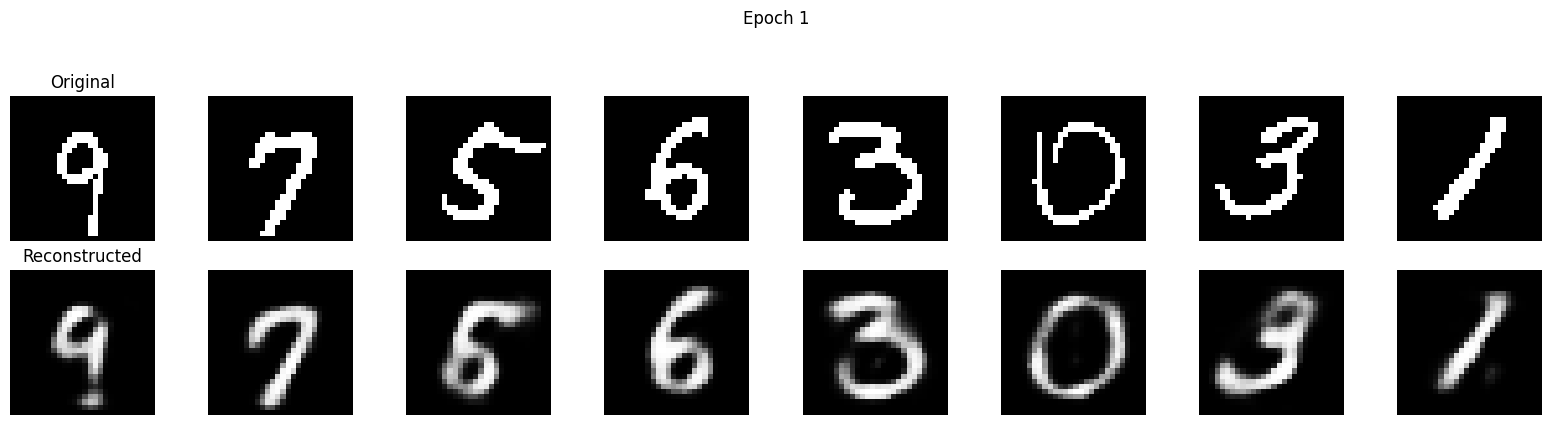

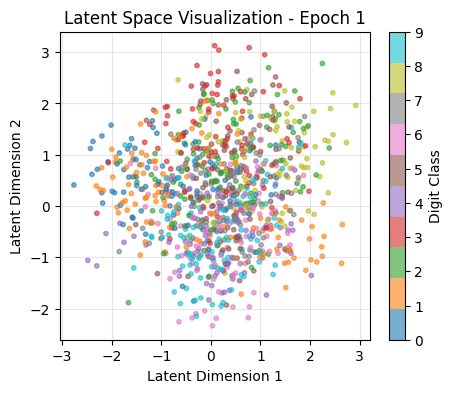

  Generated samples:
    Min: 0.0000
    Max: 0.9995
    Mean: 0.2297
    Std: 0.3193



Epoch 12/44:
 Training Details:
  Total Loss: 87.0818
  Reconstruction Loss: 56.8677
  KL Divergence: 30.2140
  Beta (KL/Recon ratio): 0.5313
 Validation Details:
  Total Loss: 87.3225
  Reconstruction Loss: 57.2802
  KL Divergence: 30.0423
  Beta (KL/Recon ratio): 0.5245


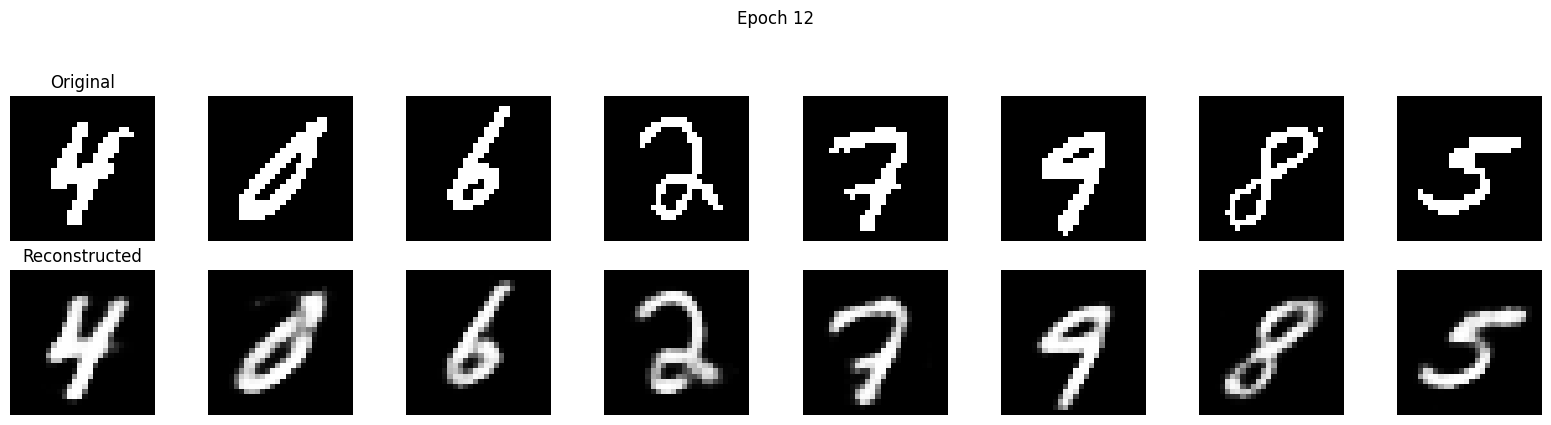

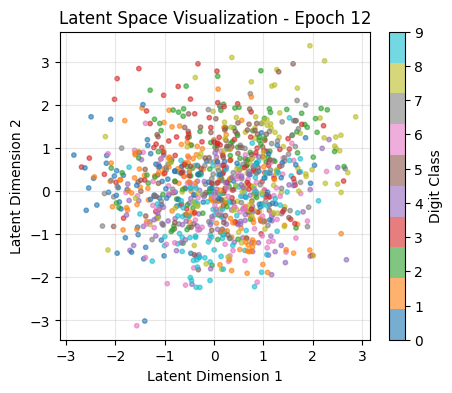

  Generated samples:
    Min: 0.0000
    Max: 1.0000
    Mean: 0.1297
    Std: 0.2933



Epoch 23/44:
 Training Details:
  Total Loss: 82.6939
  Reconstruction Loss: 51.7811
  KL Divergence: 30.9128
  Beta (KL/Recon ratio): 0.5970
 Validation Details:
  Total Loss: 84.9301
  Reconstruction Loss: 54.4457
  KL Divergence: 30.4844
  Beta (KL/Recon ratio): 0.5599


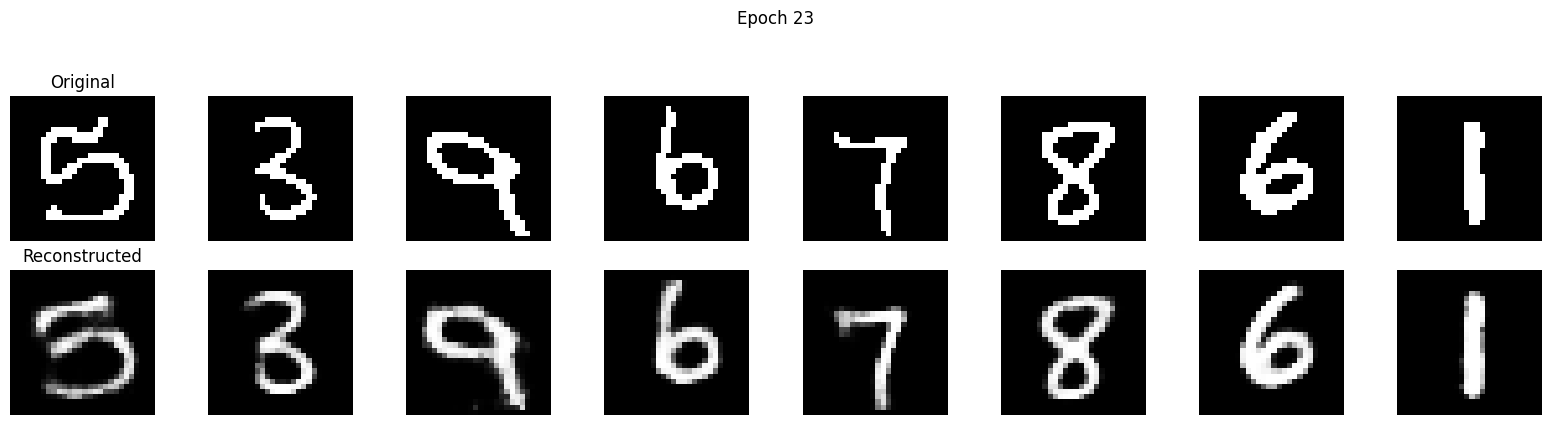

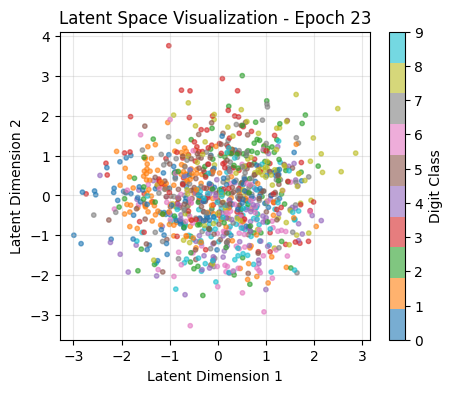

  Generated samples:
    Min: 0.0000
    Max: 1.0000
    Mean: 0.1130
    Std: 0.2769



Epoch 34/44:
 Training Details:
  Total Loss: 80.7628
  Reconstruction Loss: 49.4525
  KL Divergence: 31.3104
  Beta (KL/Recon ratio): 0.6331
 Validation Details:
  Total Loss: 84.8108
  Reconstruction Loss: 53.7556
  KL Divergence: 31.0552
  Beta (KL/Recon ratio): 0.5777


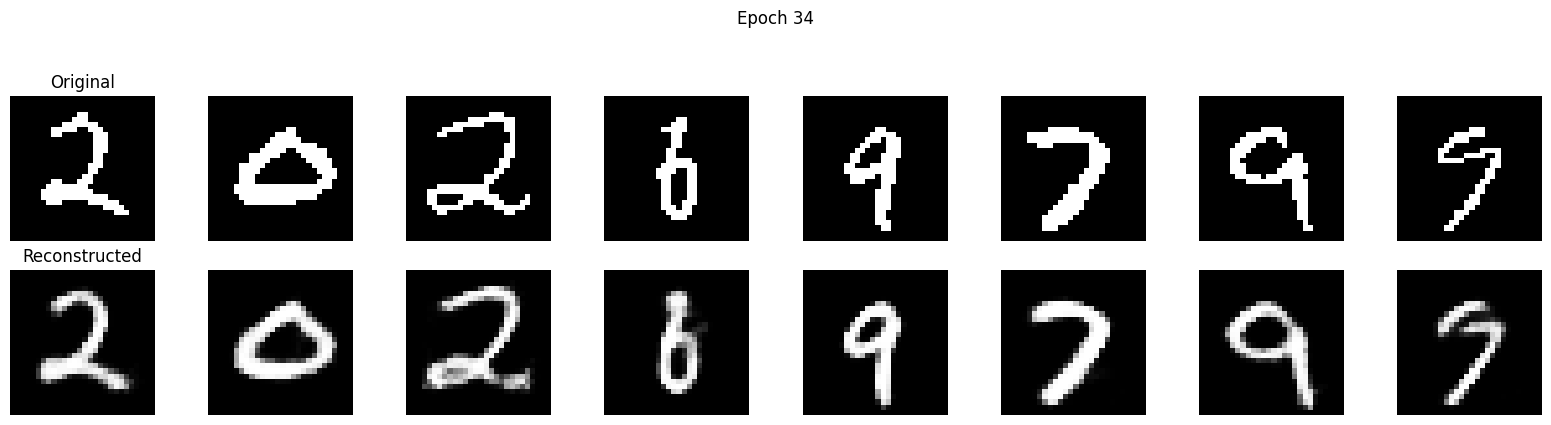

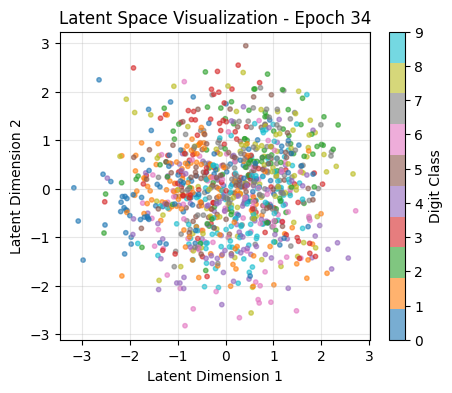

  Generated samples:
    Min: 0.0000
    Max: 1.0000
    Mean: 0.0867
    Std: 0.2376



Epoch 44/44:
 Training Details:
  Total Loss: 79.6319
  Reconstruction Loss: 48.0680
  KL Divergence: 31.5639
  Beta (KL/Recon ratio): 0.6567
 Validation Details:
  Total Loss: 84.3517
  Reconstruction Loss: 53.5370
  KL Divergence: 30.8147
  Beta (KL/Recon ratio): 0.5756


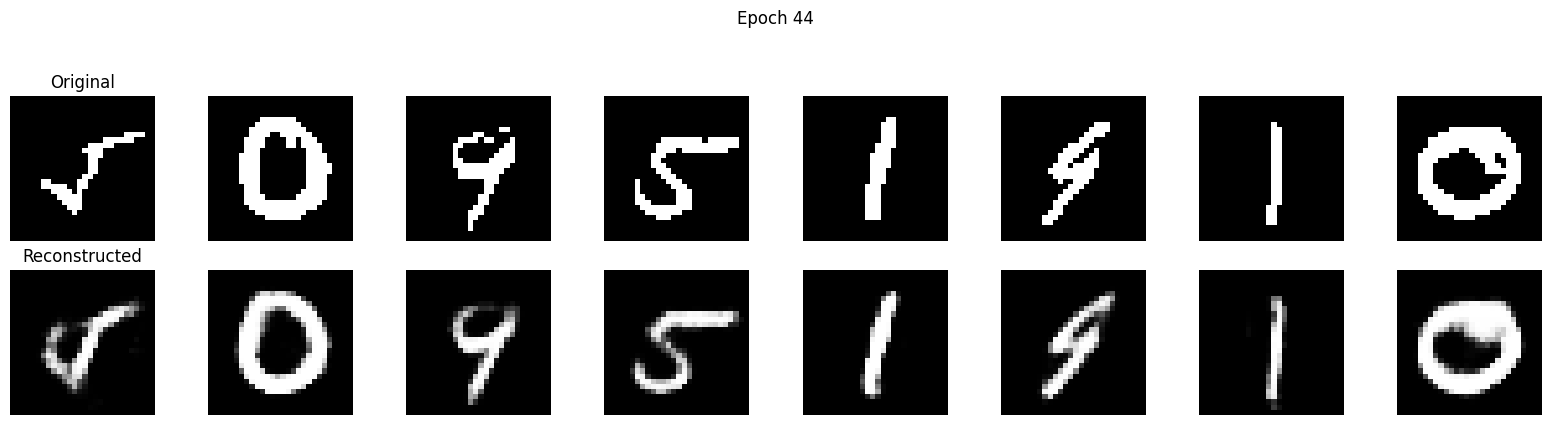

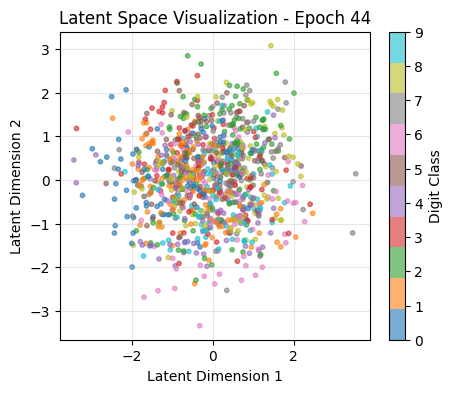

  Generated samples:
    Min: 0.0000
    Max: 1.0000
    Mean: 0.1160
    Std: 0.2839

TRAINING COMPLETE
Final Training Loss: 79.6319
Final Reconstruction Loss: 48.0680
Final KL Divergence: 31.5639
Final Testing Loss: 84.3517
Final Test Reconstruction Loss: 53.5370
Final Test KL Divergence: 30.8147
Total Epochs: 44
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
VAE                                      [128, 784]                [128, 784]                2,678,304                 True
├─Sequential: 1-1                        [128, 784]                [128, 512]                --                        True
│    └─Linear: 2-1                       [128, 784]                [128, 1024]               803,840                   True
│    └─Tanh: 2-2                         [128, 1024]               [128, 1024]               --                        --
│    └─Linear: 2-3                       [128, 1024]        

In [6]:
customVAE,optimizer,train_losses,recon_losses,kl_losses, valid_losses,valReconLosses,valKlLosses = customVAETraining(
    epochs=epochs,vaeModel=customVAE,train_loader=train_loader, val_loader=test_loader,lr=1e-3)


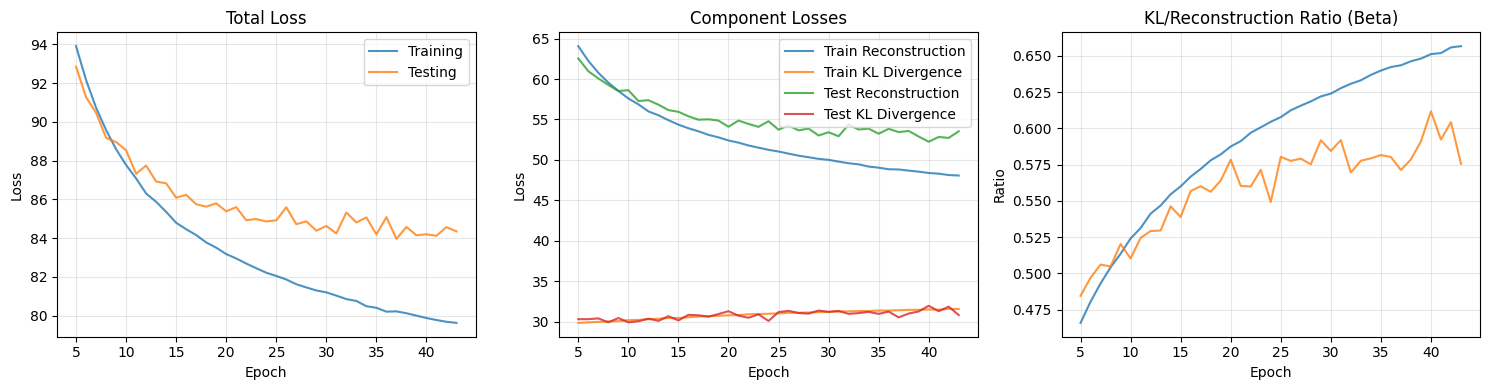

In [12]:
plotLosses(train_losses,recon_losses,kl_losses, valid_losses,valReconLosses,valKlLosses, burnEpochs=5)

In [8]:
torch.save({
    'model_state_dict': customVAE.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': {
        'data_dim': data_dim,
        'latent_dim': latent_dim,
        'hidden_dim': hidden_dim,
        'encoder_layers': encoder_layers,
        'data_type': data_type
    },
    'training_info': {
        'epochs': epochs,
        'train_losses': train_losses,
        'recon_losses': recon_losses,
        'kl_losses': kl_losses
    }
}, '../workspace/preTrainedVAE_Models/MNIST_VAE_Model/customVAE_model2.pth')